<a href="https://colab.research.google.com/github/santana-robledo/Posgrado_Robotica_e_Inteligencia_Artificial/blob/main/Sistemas%20InteligentesII/L05_red_neuronal_densa_tf.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Red Neuronal Densa en TensorFlow
## Josue Santana Robledo Corona

Paso 1. Correr paqueterias

In [ ]:
# Paquetería básica
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Importamos Tensorflow y Keras
import tensorflow as tf
from tensorflow import keras

# Usamos funcionalidades básicas de Sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

Paso 2. Carga el archivo 'auto-mpg.csv' y haz la lectura con pandas

In [ ]:
!wget 'https://github.com/Dr-Carlos-Villasenor/Clase_Aprendizaje_Profundo/raw/main/Datasets/auto-mpg.csv'

--2026-03-04 15:46:58--  https://github.com/Dr-Carlos-Villasenor/Clase_Aprendizaje_Profundo/raw/main/Datasets/auto-mpg.csv
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/Dr-Carlos-Villasenor/Clase_Aprendizaje_Profundo/main/Datasets/auto-mpg.csv [following]
--2026-03-04 15:46:58--  https://raw.githubusercontent.com/Dr-Carlos-Villasenor/Clase_Aprendizaje_Profundo/main/Datasets/auto-mpg.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 18131 (18K) [text/plain]
Saving to: ‘auto-mpg.csv’

auto-mpg.csv        100%[===================>]  17.71K  --.-KB/s    in 0s      

2026-03-04 15:46:58 (117 

In [ ]:
dataset = pd.read_csv('auto-mpg.csv')
dataset.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


Paso 3. Limpieza de los datos

In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.1+ KB


In [ ]:
np.array(dataset.horsepower)

array(['130', '165', '150', '150', '140', '198', '220', '215', '225',
       '190', '170', '160', '150', '225', '95', '95', '97', '85', '88',
       '46', '87', '90', '95', '113', '90', '215', '200', '210', '193',
       '88', '90', '95', '?', '100', '105', '100', '88', '100', '165',
       '175', '153', '150', '180', '170', '175', '110', '72', '100', '88',
       '86', '90', '70', '76', '65', '69', '60', '70', '95', '80', '54',
       '90', '86', '165', '175', '150', '153', '150', '208', '155', '160',
       '190', '97', '150', '130', '140', '150', '112', '76', '87', '69',
       '86', '92', '97', '80', '88', '175', '150', '145', '137', '150',
       '198', '150', '158', '150', '215', '225', '175', '105', '100',
       '100', '88', '95', '46', '150', '167', '170', '180', '100', '88',
       '72', '94', '90', '85', '107', '90', '145', '230', '49', '75',
       '91', '112', '150', '110', '122', '180', '95', '?', '100', '100',
       '67', '80', '65', '75', '100', '110', '105', '140', '1

In [ ]:
dataset.horsepower.unique()

array(['130', '165', '150', '140', '198', '220', '215', '225', '190',
       '170', '160', '95', '97', '85', '88', '46', '87', '90', '113',
       '200', '210', '193', '100', '105', '175', '153', '180', '110',
       '72', '86', '70', '76', '65', '69', '60', '80', '54', '208', '155',
       '112', '92', '145', '137', '158', '167', '94', '107', '230', '49',
       '75', '91', '122', '67', '83', '78', '52', '61', '93', '148',
       '129', '96', '71', '98', '115', '53', '81', '79', '120', '152',
       '102', '108', '68', '58', '149', '89', '63', '48', '66', '139',
       '103', '125', '133', '138', '135', '142', '77', '62', '132', '84',
       '64', '74', '116', '82'], dtype=object)

In [ ]:
dataset['horsepower'].replace('?', np.nan, inplace=True)
np.array(dataset.horsepower)

/tmp/ipykernel_620/1018419082.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset['horsepower'].replace('?', np.nan, inplace=True)


array(['130', '165', '150', '150', '140', '198', '220', '215', '225',
       '190', '170', '160', '150', '225', '95', '95', '97', '85', '88',
       '46', '87', '90', '95', '113', '90', '215', '200', '210', '193',
       '88', '90', '95', nan, '100', '105', '100', '88', '100', '165',
       '175', '153', '150', '180', '170', '175', '110', '72', '100', '88',
       '86', '90', '70', '76', '65', '69', '60', '70', '95', '80', '54',
       '90', '86', '165', '175', '150', '153', '150', '208', '155', '160',
       '190', '97', '150', '130', '140', '150', '112', '76', '87', '69',
       '86', '92', '97', '80', '88', '175', '150', '145', '137', '150',
       '198', '150', '158', '150', '215', '225', '175', '105', '100',
       '100', '88', '95', '46', '150', '167', '170', '180', '100', '88',
       '72', '94', '90', '85', '107', '90', '145', '230', '49', '75',
       '91', '112', '150', '110', '122', '180', '95', nan, '100', '100',
       '67', '80', '65', '75', '100', '110', '105', '140', '1

In [ ]:
dataset = dataset.dropna()

Paso 3. Revisar datos faltantes

In [ ]:
dataset.isna().sum()

,0
mpg,0
cylinders,0
displacement,0
horsepower,0
weight,0
acceleration,0
model year,0
origin,0
car name,0


In [ ]:
dataset.origin.unique()

AttributeError: 'DataFrame' object has no attribute 'origin'

Paso 6. Condificación one-hot a columnas del país

In [ ]:
origin = dataset.pop('origin')
dataset['USA'] = (origin == 1)*1.0
dataset['Europe'] = (origin == 2)*1.0
dataset['Japan'] = (origin == 3)*1.0
dataset.tail()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,car name,USA,Europe,Japan
393,27.0,4,140.0,86,2790,15.6,82,ford mustang gl,1.0,0.0,0.0
394,44.0,4,97.0,52,2130,24.6,82,vw pickup,0.0,1.0,0.0
395,32.0,4,135.0,84,2295,11.6,82,dodge rampage,1.0,0.0,0.0
396,28.0,4,120.0,79,2625,18.6,82,ford ranger,1.0,0.0,0.0
397,31.0,4,119.0,82,2720,19.4,82,chevy s-10,1.0,0.0,0.0


Paso 7. Elige las variables de entrada y salida

In [ ]:
x = np.asanyarray(dataset.drop(columns=['mpg', 'car name']))
y = np.asanyarray(dataset[['mpg']])
x = StandardScaler().fit_transform(x)
print(x.shape)
print(y.shape)

(392, 9)
(392, 1)


Paso 8. Particiona el dataset

In [ ]:
xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=0.2)

Paso 9. Crea una red neuronal para aprender los datos. En este caso creamos la metrica de regresión R2,

In [ ]:
def build_model():

  model = keras.Sequential()
  model.add(keras.layers.Dense(128, activation='relu', input_shape=[x.shape[1]]))
  model.add(keras.layers.Dropout(0.2))
  model.add(keras.layers.Dense(32, activation='tanh'))
  model.add(keras.layers.Dense(1, activation='linear'))

  model.compile(loss='mean_squared_error',
                optimizer=keras.optimizers.Adam(),
                metrics=[keras.metrics.MAE, keras.metrics.R2Score])
  return  model

In [ ]:
model = build_model()
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,441 (21.25 KB)

 Trainable params: 5,441 (21.25 KB)

 Non-trainable params: 0 (0.00 B)

Paso 10. Entrena la red neuronal

In [ ]:
history = model.fit(xtrain, ytrain,
                    batch_size=150, epochs=3000,
                    validation_data=(xtest, ytest), verbose=1)

Se truncaron las últimas líneas 5000 del resultado de transmisión.
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 11.4343 - mean_absolute_error: 2.2938 - r2_score: 0.8108 - val_loss: 10.6645 - val_mean_absolute_error: 2.2013 - val_r2_score: 0.7989
Epoch 502/3000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 11.8923 - mean_absolute_error: 2.3430 - r2_score: 0.8098 - val_loss: 10.6012 - val_mean_absolute_error: 2.1853 - val_r2_score: 0.8001
Epoch 503/3000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 11.5773 - mean_absolute_error: 2.3330 - r2_score: 0.8132 - val_loss: 10.5504 - val_mean_absolute_error: 2.1761 - val_r2_score: 0.8010
Epoch 504/3000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 11.1357 - mean_absolute_error: 2.2070 - r2_score: 0.8214 - val_loss: 10.5297 - val_mean_absolute_error: 2.1751 - val_r2_score: 0.8014
Epoch 505/3000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 11.1694 - mean_absolute_error: 2.2302 - r2_score: 0.8159 - val_loss: 10.5203 - val_mean_absolute_error: 2.1

Paso 11. Dibuja las curvas de aprendizaje para un mejor diagnóstico del aprendizaje

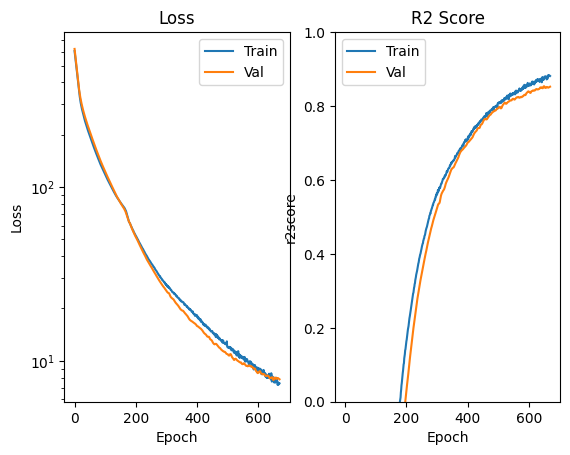

In [ ]:
def plot_history(history):
  hist = pd.DataFrame(history.history)
  hist['epoch'] = history.epoch
  plt.figure()
  plt.subplot(121)
  plt.title('Loss')
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.plot(hist['epoch'], hist['loss'],
           label='Train')
  plt.plot(hist['epoch'], hist['val_loss'],
           label = 'Val')
  plt.yscale('log')
  plt.legend()

  plt.subplot(122)
  plt.title('R2 Score')
  plt.xlabel('Epoch')
  plt.ylabel('r2score')
  plt.plot(hist['epoch'], hist['r2_score'],
           label='Train')
  plt.plot(hist['epoch'], hist['val_r2_score'],
           label = 'Val')
  plt.ylim([0,1])
  plt.legend()

plot_history(history)

Paso 12. Implementación de Eary Stopping como regulador

Epoch 1/1000


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 662ms/step - loss: 614.4336 - mean_absolute_error: 23.5683 - r2_score: -8.9273 - val_loss: 630.4652 - val_mean_absolute_error: 24.1130 - val_r2_score: -10.8911
Epoch 2/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 585.4814 - mean_absolute_error: 22.9390 - r2_score: -8.3538 - val_loss: 603.8433 - val_mean_absolute_error: 23.5651 - val_r2_score: -10.3890
Epoch 3/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 568.1852 - mean_absolute_error: 22.5972 - r2_score: -8.2236 - val_loss: 578.1882 - val_mean_absolute_error: 23.0269 - val_r2_score: -9.9051
Epoch 4/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 542.6298 - mean_absolute_error: 22.0346 - r2_score: -7.8307 - val_loss: 553.5651 - val_mean_absolute_error: 22.4955 - val_r2_score: -9.4407
Epoch 5/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 508.3256 - mean_absolute_error: 21.2392 - r2_score: -7.1866 - val_loss: 529.7168 - val_mean_absolute_error: 21.9680 - val_r2_score: -8.9909
Epoch 6/1000
3/

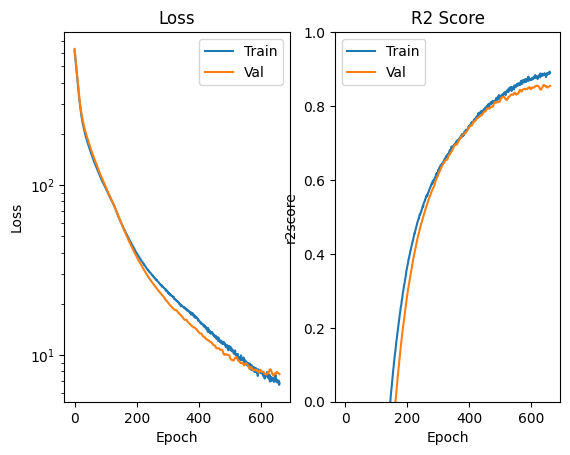

In [ ]:
es = keras.callbacks.EarlyStopping(monitor='val_loss', mode='min', patience=20)
model = build_model()
history = model.fit(xtrain, ytrain,
                    batch_size=150, epochs=1000,
                    validation_data=(xtest, ytest),
                    verbose=1, callbacks=[es])
plot_history(history)